<a href="https://colab.research.google.com/github/MoeinSheikhottayefe/Networkx/blob/main/centrality_meansures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx

This code filters nodes based on the number of their neighbors. One way to do this is by using:

len(list(G.neighbors(n)))

The neighbors method takes a node as input, so we need to iterate over all nodes in the graph. Fortunately, G.nodes() returns an iterable, which makes this straightforward. We then convert the neighbors iterator into a list, because the len() function requires a sized container in order to compute the number of elements.

In [3]:
import networkx as nx

# ==========================================
# 1. Function: nodes with m neighbors
# ==========================================
def nodes_with_m_nbrs(G, m):
    """
    Returns all nodes in graph G that have exactly m neighbors (degree = m).
    """
    nodes = set()

    for n in G.nodes():
        # بهتر از list(G.neighbors) استفاده نکنیم → مستقیم len(iterable)
        if len(list(G.neighbors(n))) == m:
            nodes.add(n)

    return nodes


# ==========================================
# 2. Create a sample graph
# ==========================================
T = nx.Graph()

T.add_edges_from([
    (0, 1), (0, 2), (0, 3),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5), (4, 6), (4, 7),
    (5, 6)
])

# ==========================================
# 3. Find nodes with exactly m neighbors
# ==========================================
m = 3
nodes_m = nodes_with_m_nbrs(T, m)

print(f"Nodes with degree = {m}: {nodes_m}")

Nodes with degree = 3: {0, 2, 3}


A better way to achieve this goal is by using the G.degree() method. The G.degree() function returns an iterable of pairs in the form (node, degree). Therefore, when iterating over it, we need two variables to unpack each element.

The nodes_with_degree function returns a set using a set comprehension, which provides a more concise and efficient way to filter nodes based on their degree.

In [4]:

def nodes_with_degree(G, m):
    return {n for n, d in G.degree() if d == m}


T = nx.Graph()
T.add_edges_from([
    (0, 1), (0, 2), (0, 3),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5), (4, 6), (4, 7),
    (5, 6)
])

result = nodes_with_degree(T, 3)

print(result)

{0, 2, 3}


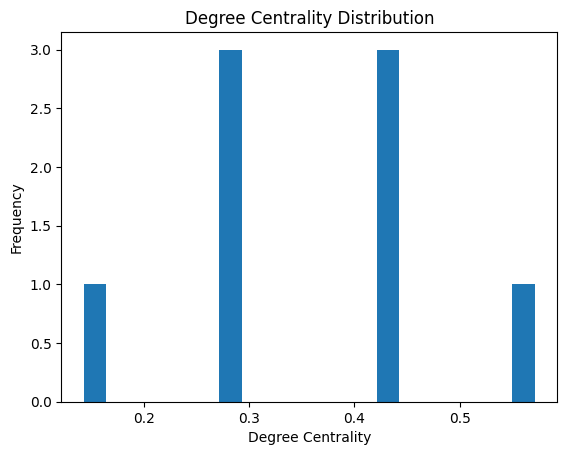

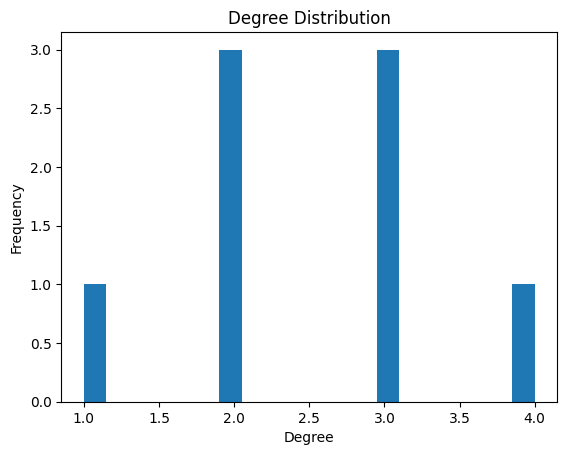

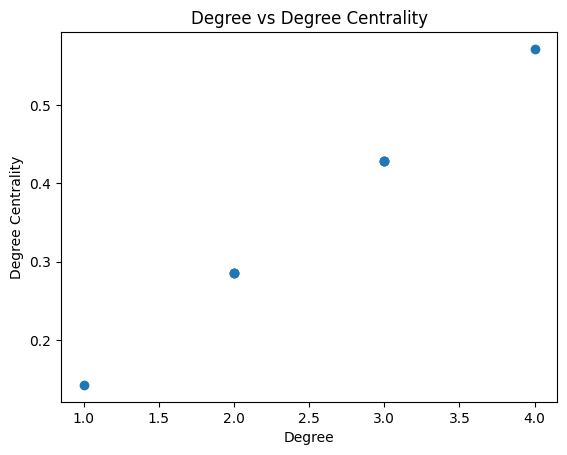

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Assume T is your graph (Twitter network or any graph)
# Example (if you don't already have it):
# T = nx.karate_club_graph()

# ==========================================
# 1. Degree centrality
# ==========================================
deg_cent = nx.degree_centrality(T)

# ==========================================
# 2. Degree values (raw degree)
# ==========================================
degrees = [d for n, d in T.degree()]

# ==========================================
# 3. Histogram: degree centrality distribution
# ==========================================
plt.figure()
plt.hist(list(deg_cent.values()), bins=20)
plt.title("Degree Centrality Distribution")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 4. Histogram: degree distribution
# ==========================================
plt.figure()
plt.hist(degrees, bins=20)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 5. Scatter: degree vs centrality
# ==========================================
plt.figure()
plt.scatter(degrees, list(deg_cent.values()))
plt.title("Degree vs Degree Centrality")
plt.xlabel("Degree")
plt.ylabel("Degree Centrality")
plt.show()

In [6]:
import networkx as nx
import urllib.request
import gzip
import shutil

# ==========================================
# 1. Download dataset
# ==========================================
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
file_gz = "facebook_combined.txt.gz"
file_txt = "facebook_combined.txt"

urllib.request.urlretrieve(url, file_gz)

# Unzip file
with gzip.open(file_gz, 'rb') as f_in:
    with open(file_txt, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# ==========================================
# 2. Load graph into NetworkX
# ==========================================
F = nx.read_edgelist(file_txt, create_using=nx.Graph(), nodetype=int)

print("Number of nodes:", F.number_of_nodes())
print("Number of edges:", F.number_of_edges())

Number of nodes: 4039
Number of edges: 88234


In [7]:
# Degree centrality
deg_cent = nx.degree_centrality(F)

# Top 5 most connected nodes
top_nodes = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop influential nodes:")
for node, score in top_nodes:
    print(node, "->", round(score, 4))


Top influential nodes:
107 -> 0.2588
1684 -> 0.1961
1912 -> 0.187
3437 -> 0.1355
0 -> 0.0859


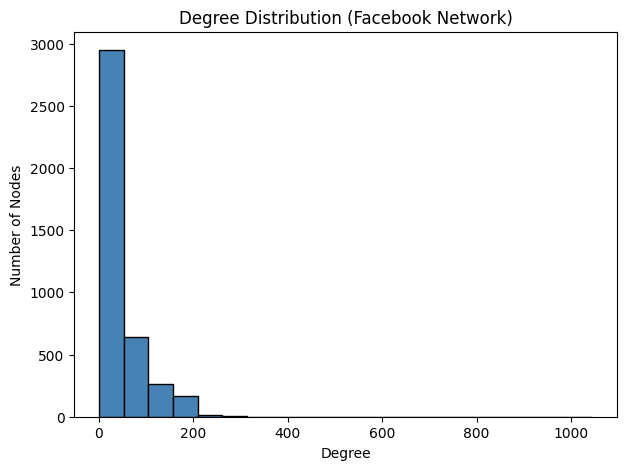

In [9]:
import matplotlib.pyplot as plt

# degrees of all nodes
degrees = [d for n, d in F.degree()]

# plot histogram
plt.figure(figsize=(7,5))

plt.hist(degrees, bins=20, color='steelblue', edgecolor='black')

plt.title("Degree Distribution (Facebook Network)")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")

plt.show()

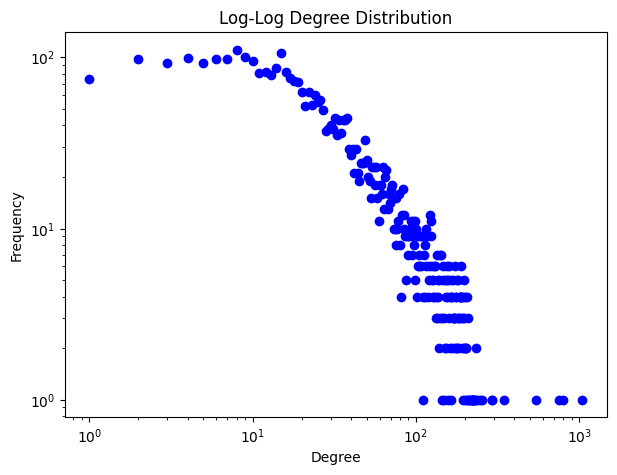

In [10]:
import numpy as np
import matplotlib.pyplot as plt

degrees = [d for n, d in F.degree()]

# count frequency of each degree
unique_deg, counts = np.unique(degrees, return_counts=True)

plt.figure(figsize=(7,5))

plt.loglog(unique_deg, counts, 'bo')

plt.title("Log-Log Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")

plt.show()